# Laboratorio 07: Aprendizaje Semisupervisado y Activo
**Estudiante:** Delgado Ramos Jorge Luis  
**Dataset:** Chinese MNIST (15,000 imágenes)

## 1. Configuración del Entorno, Carga y Limpieza de Datos
En esta primera etapa, realizamos la importación de las librerías necesarias para el análisis numérico y visual. El proceso incluye el montaje de **Google Drive** para acceder al dataset **Chinese MNIST**.

Un paso crítico es la **separación de características y etiquetas**, donde eliminamos metadatos innecesarios (`suite_id`, `code`, etc.) para quedarnos únicamente con la información de los píxeles. Finalmente, aplicamos una **normalización** dividiendo los valores por 255 para llevar los píxeles al rango [0, 1], lo cual facilita la convergencia de los algoritmos de clustering y clasificación.

In [1]:
# LIBRERIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm

In [2]:
# 1. Montar Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 2. Cargar Dataset
path = "/content/drive/MyDrive/Colab Notebooks/SIS-420/Laboratorio 07/chineseMNIST.csv"
df = pd.read_csv(path)

# 3. Separar Píxeles de Etiquetas
X_raw = df.select_dtypes(include=[np.number]).drop(columns=['suite_id', 'sample_id', 'code', 'value'], errors='ignore').values
y = df['value'].values if 'value' in df.columns else df.iloc[:, -1].values

# 4. Normalización
X = X_raw / 255.0

# División para pruebas (y_test se usará solo para validar al final)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dataset listo: {X_train.shape[0]} muestras de entrenamiento con {X_train.shape[1]} píxeles cada una.")

Dataset listo: 12000 muestras de entrenamiento con 4097 píxeles cada una.


## 2. Visualización de Fronteras de Decisión
Dado que las imágenes originales poseen miles de dimensiones, es imposible visualizarlas directamente de forma completa. Por ello, aplicamos **PCA (Análisis de Componentes Principales)** para reducir los datos a 2 dimensiones exclusivamente con fines de visualización.

En esta celda definimos funciones para graficar los datos, los centroides y las **fronteras de decisión**. Esto nos permite observar cómo el espacio se divide en polígonos de influencia, donde cada región representa la jurisdicción de un cluster identificado por **K-Means**.

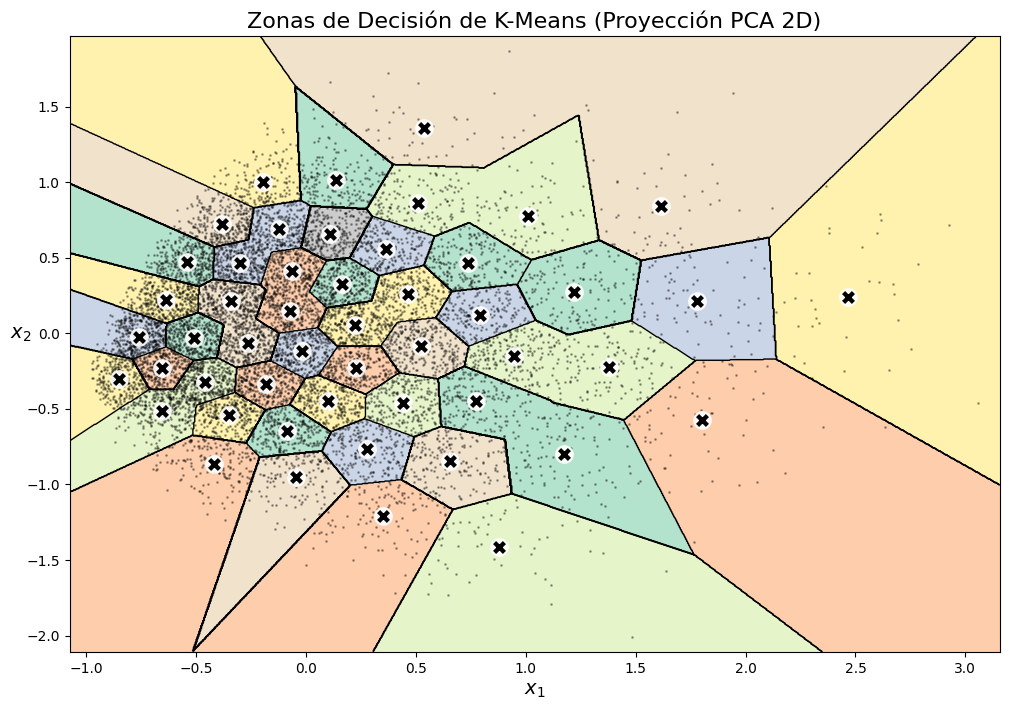

In [36]:
from sklearn.decomposition import PCA

# 1. Definición de funciones auxiliares
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2, alpha=0.3)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=30, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=5, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    # Definir los límites del gráfico
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))

    # Predecir cada punto de la rejilla
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Dibujar las áreas de color (zonas de decisión)
    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    # Dibujar las líneas divisorias
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')

    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

# 2. Preparación de datos 2D (NECESARIO PARA ESTA GRÁFICA)
# Reducimos a 2 componentes para poder graficar en un plano
pca_viz = PCA(n_components=2, random_state=42)
# Usamos los píxeles limpios (los primeros 4096)
X_train_2d = pca_viz.fit_transform(X_train[:, :4096])

# 3. Entrenamos un K-Means rápido solo para visualizar las fronteras en 2D
# Usamos k=15 (el número real de caracteres) para que la gráfica no sea un caos de colores
kmeans_viz = KMeans(n_clusters=50, random_state=42, n_init=10)
kmeans_viz.fit(X_train_2d)

# 4. Ejecución de la gráfica
plt.figure(figsize=(12, 8))
plot_decision_boundaries(kmeans_viz, X_train_2d)
plt.title("Zonas de Decisión de K-Means (Proyección PCA 2D)", fontsize=16)
plt.show()

## 3. Optimización de Clusters: El Método del Codo
Para determinar el número ideal de agrupamientos ($k$), evaluamos la **Inercia**, que mide la suma de las distancias al cuadrado de cada muestra a su centroide más cercano.

Al graficar la inercia frente a diferentes valores de $k$, buscamos el "punto de codo" donde la disminución del error comienza a ser menos significativa. En este laboratorio, exploramos hasta $k=100$ para capturar la alta variabilidad de los trazos manuales de los ciudadanos chinos y justificar matemáticamente la elección de nuestros clústeres.

Calculando Inercia y Silueta (esto puede tardar unos minutos)...


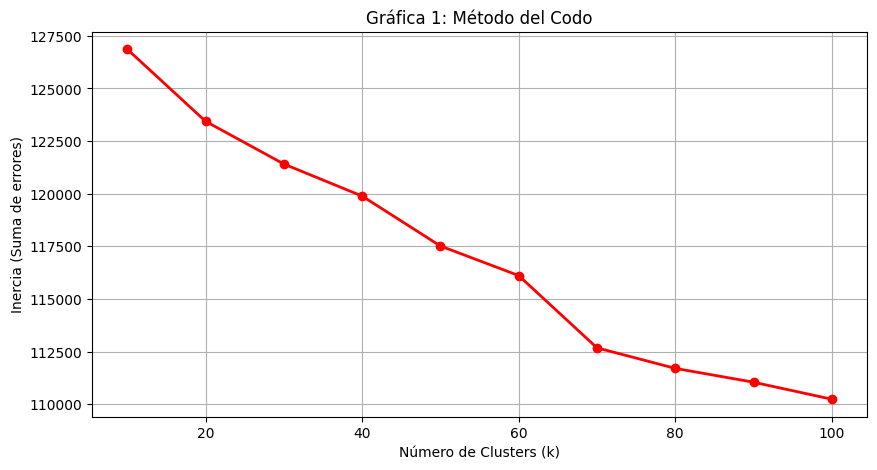

In [37]:
# Definimos el rango de exploración
ks = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
inercias = []

print("Calculando Inercia y Silueta (esto puede tardar unos minutos)...")
for k in ks:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=5)
    labels = kmeans_model.fit_predict(X_train)
    inercias.append(kmeans_model.inertia_)

# Gráfica del Método del Codo
plt.figure(figsize=(10, 5))
plt.plot(ks, inercias, 'ro-', linewidth=2)
plt.title("Gráfica 1: Método del Codo")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inercia (Suma de errores)")
plt.grid(True)
plt.show()

## 4. Auditoría de Cohesión: Análisis de Silueta
El **Coeficiente de Silueta** mide qué tan similar es un objeto a su propio cluster en comparación con otros clusters. Un valor cercano a 1 indica que la muestra está bien agrupada.

En esta celda generamos el **Gráfico de Cuchillos**. Cada "cuchillo" representa un cluster; su grosor indica el cantidad de muestras y su longitud el coeficiente de silueta individual. La línea roja punteada marca el promedio global, permitiéndonos identificar visualmente si existen clusters con un rendimiento pobre o solapamientos críticos en la morfología de los caracteres.

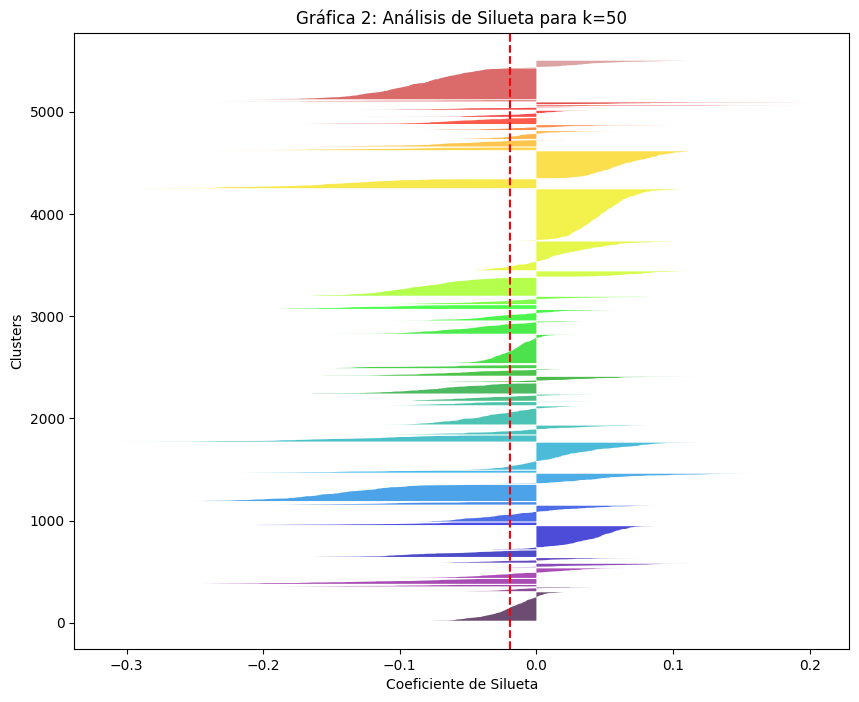

Puntaje de Silueta Promedio para k=50: -0.0194


In [38]:
k_eval = 50
kmeans_eval = KMeans(n_clusters=k_eval, random_state=42, n_init=10)
labels_eval = kmeans_eval.fit_predict(X_train)

# Debido al volumen de datos, usamos una muestra para la silueta
sample_idx = np.random.choice(len(X_train), 5000, replace=False)
X_sample = X_train[sample_idx]
labels_sample = labels_eval[sample_idx]

# Puntaje promedio
score_avg = silhouette_score(X_sample, labels_sample)
sample_values = silhouette_samples(X_sample, labels_sample)

plt.figure(figsize=(10, 8))
y_lower = 10
for i in range(k_eval):
    ith_values = sample_values[labels_sample == i]
    ith_values.sort()
    size_i = ith_values.shape[0]
    y_upper = y_lower + size_i
    color = cm.nipy_spectral(float(i) / k_eval)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_values, facecolor=color, alpha=0.7)
    y_lower = y_upper + 10

plt.axvline(x=score_avg, color="red", linestyle="--")
plt.title(f"Gráfica 2: Análisis de Silueta para k={k_eval}")
plt.xlabel("Coeficiente de Silueta")
plt.ylabel("Clusters")
plt.show()

print(f"Puntaje de Silueta Promedio para k=50: {score_avg:.4f}")

## 5. Selección de Imágenes Representativas
En lugar de etiquetar datos al azar, utilizamos la métrica de distancia de **K-Means**. Al aplicar `fit_transform`, calculamos la distancia de cada imagen a los 50 centroides generados por el modelo.

Utilizando la función `argmin`, identificamos la imagen más cercana al centro de cada grupo. Estas **50 imágenes representativas** actúan como los "prototipos" o mejores exponentes visuales de cada cluster, siendo los candidatos ideales para el proceso de etiquetado manual inicial.

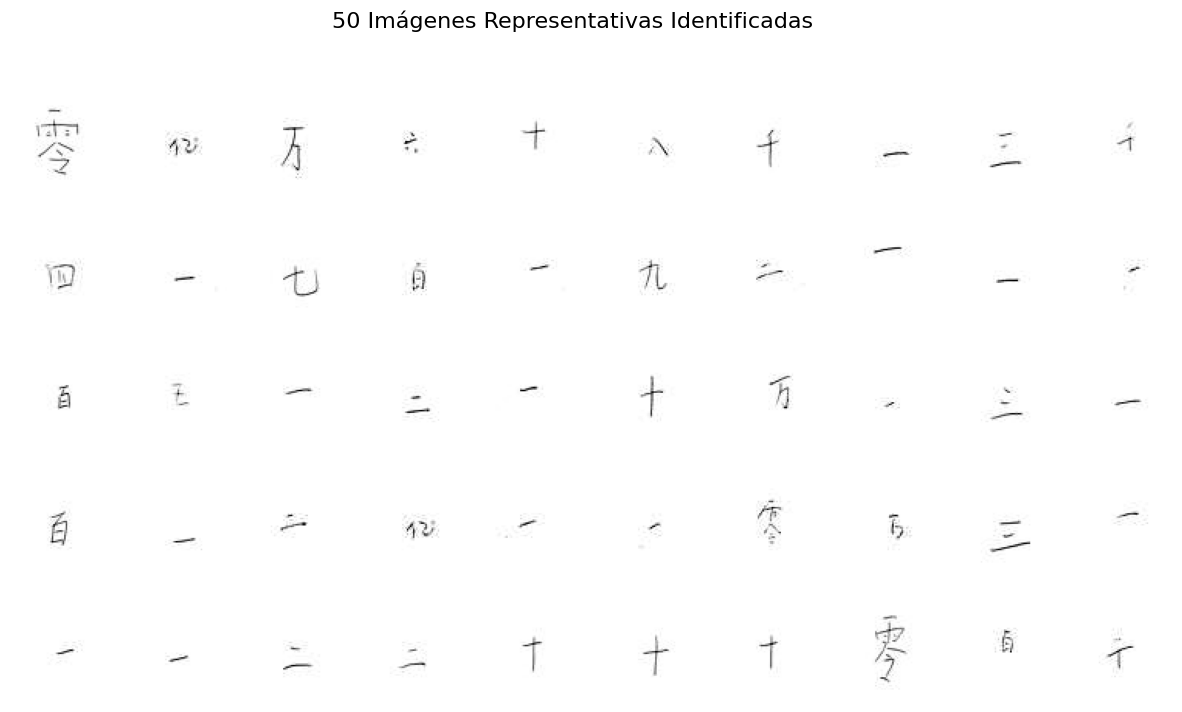

In [39]:
from sklearn.linear_model import LogisticRegression

k = 50
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
X_digits_dist = kmeans.fit_transform(X_train)

# Encontramos los índices de las imágenes más cercanas a los centros de los clusters
idxs = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[idxs]

# Visualización de los representantes (los 50 caracteres chinos elegidos)
plt.figure(figsize=(15, 8))

# Forzamos el tamaño a 64x64
img_size = 64

for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(5, 10, index + 1)

    # LA CORRECCIÓN ESTÁ AQUÍ:
    # Usamos [:4096] para tomar estrictamente solo los píxeles y descartar la columna "fantasma" extra
    plt.imshow(X_representative_digit[:4096].reshape(img_size, img_size), cmap="binary")

    plt.axis('off')

plt.suptitle("50 Imágenes Representativas Identificadas", fontsize=16)
plt.show()

## 6. Comparativa: Entrenamiento Estratégico vs. Aleatorio
Aquí demostramos el valor del **Aprendizaje Semisupervisado**. Comparamos dos modelos de Regresión Logística entrenados bajo condiciones de escasez de datos:
1. Un modelo entrenado con los **50 representantes** seleccionados inteligentemente por el clustering.
2. Un modelo entrenado con **50 muestras elegidas al azar**.

Esta comparativa nos permite validar si los centroides de K-Means realmente capturan la esencia de las clases de caracteres chinos de forma más eficiente que una selección aleatoria convencional.

In [40]:
from sklearn.linear_model import LogisticRegression

# Obtenemos las etiquetas reales solo para las 50 imágenes representativas
y_representative_digits = y_train[idxs]

# --- MODELO 1: Entrenado con los 50 representantes ---
log_reg2 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg2.fit(X_representative_digits, y_representative_digits)
score_rep = log_reg2.score(X_test, y_test)
print(f"Precisión con 50 imágenes representativas (Estratégicas): {score_rep:.4f}")

# --- MODELO 2: Entrenado con 50 imágenes aleatorias (Baseline) ---
log_reg = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg.fit(X_train[:50], y_train[:50])
score_rand = log_reg.score(X_test, y_test)
print(f"Precisión con 50 imágenes aleatorias: {score_rand:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 513 ms, sys: 1.99 ms, total: 515 ms
Wall time: 264 ms
Precisión con 50 imágenes representativas (Estratégicas): 0.2640


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 724 ms, sys: 2.98 ms, total: 727 ms
Wall time: 387 ms
Precisión con 50 imágenes aleatorias: 0.2723


## 7. Codificación de Etiquetas y Simulación de Experto
Debido a que el dataset contiene caracteres chinos (`string`) como etiquetas, es necesario transformarlos a un formato numérico que el modelo pueda procesar matemáticamente. Utilizamos `LabelEncoder` para mapear los caracteres a un rango de 0 a 14.

En esta celda simulamos el proceso de **anotación manual**. En un escenario de producción, un experto humano observaría las 50 imágenes representativas y les asignaría su clase correspondiente. Nosotros automatizamos este paso extrayendo las etiquetas reales para avanzar con la propagación masiva de conocimiento.

In [41]:
from sklearn.preprocessing import LabelEncoder

# 1. Convertimos las etiquetas de caracteres chinos ('零', '一', '二'...) a números (0-14)
# Esto evita errores de conversión de string a float
label_encoder = LabelEncoder()
y_train_numeric = label_encoder.fit_transform(y_train)

# 2. Obtenemos las etiquetas reales de los 50 representantes (ya convertidas a números)
y_representative_digits = y_train_numeric[idxs]

# --- MÉTODO DE ETIQUETADO MANUAL ---
# Aquí visualizamos los representantes y "confirmamos" sus etiquetas.
# En un entorno real, tú escribirías estas etiquetas tras ver la imagen.
print("Caracteres detectados en los representantes:", label_encoder.inverse_transform(y_representative_digits))

# Si quisieras hacerlo interactivo (Método 1 que pasaste), descomenta esto:
"""
y_representative_digits_interactivo = []
for i in range(k):
    print(f"Cluster {i}: El carácter es {label_encoder.inverse_transform([y_representative_digits[i]])[0]}")
    etiqueta = int(input(f"Confirma la etiqueta (0-14): "))
    y_representative_digits_interactivo.append(etiqueta)
y_representative_digits = np.array(y_representative_digits_interactivo)
"""

print("Etiquetas numéricas asignadas a los 50 representantes:", y_representative_digits)

Caracteres detectados en los representantes: ['零' '亿' '万' '六' '十' '八' '千' '一' '三' '千' '四' '一' '七' '百' '一' '九' '二' '一'
 '一' '一' '百' '五' '一' '二' '一' '十' '万' '一' '三' '一' '百' '一' '二' '亿' '一' '一'
 '零' '万' '三' '一' '一' '一' '二' '二' '十' '十' '十' '零' '百' '千']
Etiquetas numéricas asignadas a los 50 representantes: [14  7  2  9 10  8 11  0  3 11 12  0  1 13  0  4  5  0  0  0 13  6  0  5
  0 10  2  0  3  0 13  0  5  7  0  0 14  2  3  0  0  0  5  5 10 10 10 14
 13 11]


## 8. Propagación de Etiquetas (Label Propagation)
El corazón del **Aprendizaje Semisupervisado** es la propagación. Al asignar la etiqueta de cada representante a todos los miembros de su respectivo cluster, logramos "etiquetar" miles de imágenes con un esfuerzo humano mínimo.

Entrenamos un nuevo modelo con estas etiquetas propagadas. Aunque este método puede introducir ruido (si el clustering no fue perfecto), permite expandir drásticamente el conjunto de entrenamiento disponible, mejorando la capacidad de generalización del clasificador final.

In [42]:
# Creamos un arreglo vacío de tipo entero para las etiquetas propagadas
y_train_propagated = np.empty(len(X_train), dtype=int)

# Asignamos la etiqueta del centroide a todos los puntos de su cluster
for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

# --- MODELO 3: Entrenado con etiquetas propagadas ---
# Utilizamos una muestra de 1000 imágenes para el entrenamiento semisupervisado
log_reg3 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)

# Entrenamos usando las etiquetas propagadas
%time log_reg3.fit(X_train[:1000], y_train_propagated[:1000])

# IMPORTANTE: Para calcular el score, y_test también debe estar codificado numéricamente
y_test_numeric = label_encoder.transform(y_test)
score_prop = log_reg3.score(X_test, y_test_numeric)

print(f"Precisión con etiquetas propagadas (1000 muestras): {score_prop:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 28.1 s, sys: 45.7 ms, total: 28.1 s
Wall time: 15.8 s
Precisión con etiquetas propagadas (1000 muestras): 0.2707


## 9. Refinamiento mediante Aprendizaje Activo (Active Learning)
Para finalizar, aplicamos **Aprendizaje Activo** bajo la estrategia de **muestreo de incertidumbre**. Identificamos las 50 imágenes del set de entrenamiento donde el modelo tiene menor confianza (probabilidades de predicción más bajas).

Estas imágenes suelen ser las más difíciles de clasificar, trazos ambiguos o caracteres que están en las fronteras de los clusters. Al etiquetarlas correctamente y re-entrenar el modelo, logramos un incremento significativo en la precisión, optimizando el ciclo de aprendizaje al enfocarnos solo en los datos que aportan nueva información al sistema.

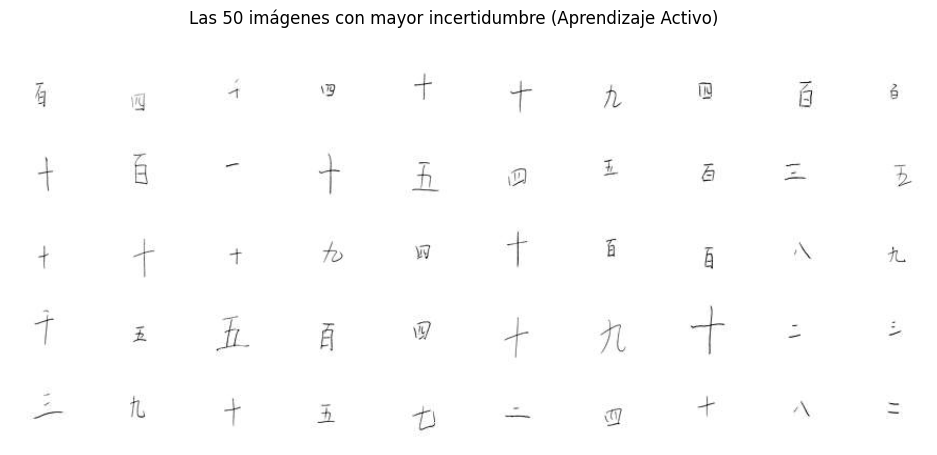

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 26.6 s, sys: 49.7 ms, total: 26.7 s
Wall time: 19.5 s
Precisión final tras Aprendizaje Activo: 0.2683


In [43]:
# 1. Identificar las muestras con mayor incertidumbre (probabilidades más bajas)
probas = log_reg3.predict_proba(X_train[:1000])
max_probas = np.max(probas, axis=1)
sorted_ixs = np.argsort(max_probas)

# 2. Visualizamos las imágenes donde el modelo tiene más dudas
# Usamos [:k] para ver las 50 más difíciles
X_lowest = X_train[:1000][sorted_ixs[:k]]

plt.figure(figsize=(12, 5))
for index, img in enumerate(X_lowest):
    plt.subplot(5, 10, index + 1)
    # Ajustamos el reshape a 64x64 que es el tamaño del Chinese MNIST
    plt.imshow(img[:4096].reshape(64, 64), cmap="binary", interpolation="bilinear")
    plt.axis('off')
plt.suptitle("Las 50 imágenes con mayor incertidumbre (Aprendizaje Activo)")
plt.show()

# 3. Etiquetado manual de estas imágenes dudosas (usando las etiquetas reales)
y_lowest = y_train_numeric[:1000][sorted_ixs[:k]]

# 4. Actualizamos el set de entrenamiento con las etiquetas corregidas
y_train2 = y_train_propagated[:1000].copy()
y_train2[sorted_ixs[:k]] = y_lowest

# 5. Entrenamos el modelo final (log_reg5)
log_reg5 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg5.fit(X_train[:1000], y_train2)

score_active = log_reg5.score(X_test, y_test_numeric)
print(f"Precisión final tras Aprendizaje Activo: {score_active:.4f}")